In [1]:
import sys
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Lecture 5: Create a Basic Neural Network

```mermaid
---
title: Nerual Network Diagram
---
flowchart LR
    A["**Input Layer**
    4 Features of Iris"] --> B["**Hidden Layer 1**
    Number of Neurons"]
    B --> C["**Hidden Layer 2**
    Number of Neurons"]
    C --> D["**Output**
    Classes of Iris"]
```

## Section 1: Create a Model Class that Inherits nn.Module

In [2]:
class Model(nn.Module):
    def __init__(self, input_features=4, h1=8, h2=9, output_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, output_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

## Section 2: Pick a manual seed for randomization and Create an instance of Model

In [3]:
torch.manual_seed(48)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = Model().to(device)
device

device(type='mps')

# Lecture 6: Load Data and Train Neural Network Model

## Section 1: Data Preprocessing
1. Load Iris Data.
2. Set X, y. And convert data type.
    * X default datatype is float64, but tensor only support float32. Must convert to float 32 or will cause error.
    * y default datatype is int64, can convert to float32 or numpy int_, won't cause error if not make changes.
3. Split train and test datasets. Convert into Tensor.
    * Method 1: Concisely, Recommended ✅
    * Method 2: Originally, Not Recommended ❌
        * Step 1: Train Test Split:
          ```{python}
          X_train, X_test, y_train, y_test = train_test_split(X, y)
          ```
        * Step 2: Convert Datasets into Tensor:
          ```{python}
          X_train = torch.tensor(X_train)
          X_test = torch.tensor(X_test)
          y_train = torch.tensor(y_train)
          y_test = torch.tensor(y_test)
          ```

In [4]:
iris = pd.read_csv(r"../datasets/iris.csv")
iris["variety"], uniques = pd.factorize(iris["variety"])

X = iris.drop(columns="variety").astype(np.float32).to_numpy()
y = iris["variety"].astype(np.int_).to_numpy()

X_train, X_test, y_train, y_test = [torch.tensor(data).to(device) for data in train_test_split(X, y, random_state=50)]

## Section 2: Setting Model Parameters
1. Set the criterion of model to measure the error, how far off the predictions are from the data.
2. Choose Adam optimizer.
3. If error doesn't go down after a bunch of iteration (epochs), lower learning rate.

### Terminology:
* lr: Learning Rate
* Epochs: one run through all the training data in our network

In [5]:
criterion = nn.CrossEntropyLoss()
optimizor = torch.optim.Adam(model.parameters(), lr=0.1)

## Section 3: Train Our Model
1. Use tqdm to show training progress.
2. Go forward and get a prediction.
3. Measure the train_loss / error, going to be high at first.
4. Keep track of our losses, and print them out.
5. Do some back propagation: take the error rate of forward propagation and feed it back through the network to find tune weights.

In [6]:
epochs = 200
losses = []
pbar = tqdm(range(epochs), desc="Training Progress", unit="epochs", file=sys.stdout)
for idx in pbar:
    y_prediction = model(X_train)
    train_loss = criterion(y_prediction, y_train)
    losses.append(train_loss.item())
    pbar.set_postfix({"loss": f"{train_loss:.4f}"})

    optimizor.zero_grad()
    train_loss.backward()
    optimizor.step()

Training Progress: 100%|██████████| 200/200 [00:10<00:00, 18.90epochs/s, loss=0.0334]


## Section 4: Graph it out

Text(0.5, 1.0, 'Learning Curve')

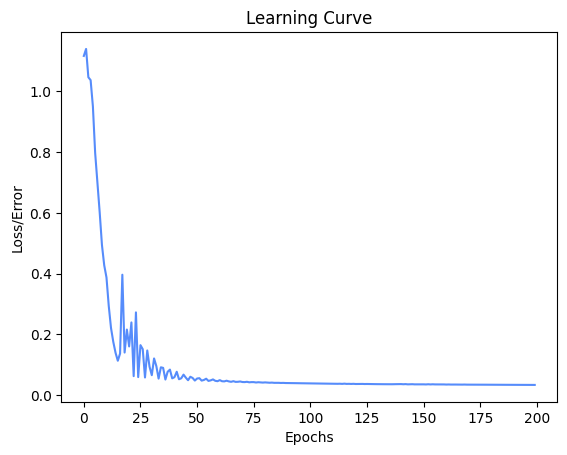

In [7]:
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Error")
plt.xlabel("Epochs")
plt.title("Learning Curve")

# Lecture 7: Evaluate Test Data Set on Network

## Section 1: Overall Evaluation on Test Datasets

In [8]:
with torch.no_grad():
    y_eval = model(X_test)
    test_loss = criterion(y_eval, y_test)

test_loss

tensor(0.1227, device='mps:0')

## Section 2: Detailed Evaluation on Test Datasets
### Quick note for .item() Method:
* A method for extracting value from a single-element array or tensor as a standard Python scalar.
* Useful when the argmax() operation results in a single index.
* E.g., from a 1D array or when finding the maximum across a specific dimension that collapses the output to a single value.

In [9]:
correct = 0
with torch.no_grad():
    for idx, data in enumerate(X_test):
        y_eval = model(data)
        print(f"{idx+1}:\t{y_eval} \t {uniques[y_eval.argmax().item()]} \t {uniques[y_test[idx].item()]}")

        if y_eval.argmax() == y_test[idx]:
            correct += 1

print(f"We got {correct} / {len(X_test)}!")

1:	tensor([ -2.6916,   8.7362, -10.3886], device='mps:0') 	 Versicolor 	 Versicolor
2:	tensor([-14.5979,   3.7330,   5.6757], device='mps:0') 	 Virginica 	 Versicolor
3:	tensor([ 29.2827,  16.1480, -63.7608], device='mps:0') 	 Setosa 	 Setosa
4:	tensor([ 33.7250,  17.1178, -72.7667], device='mps:0') 	 Setosa 	 Setosa
5:	tensor([-17.5751,   3.5189,   8.1876], device='mps:0') 	 Virginica 	 Virginica
6:	tensor([-21.4117,   3.1210,  11.6003], device='mps:0') 	 Virginica 	 Virginica
7:	tensor([-18.3462,   3.0786,   9.4038], device='mps:0') 	 Virginica 	 Virginica
8:	tensor([ 25.9825,  15.3379, -57.0308], device='mps:0') 	 Setosa 	 Setosa
9:	tensor([ 27.6790,  15.0618, -60.1853], device='mps:0') 	 Setosa 	 Setosa
10:	tensor([-14.6606,   3.6048,   5.9097], device='mps:0') 	 Virginica 	 Versicolor
11:	tensor([ 29.7581,  15.9078, -64.5730], device='mps:0') 	 Setosa 	 Setosa
12:	tensor([-20.1792,   3.4620,  10.1841], device='mps:0') 	 Virginica 	 Virginica
13:	tensor([ 27.3230,  15.1792, -59.549

# Lecture 8: New Data on the Network

In [10]:
new_iris1 = torch.tensor([4.7, 3.2, 1.3, 0.2]).to(device)
new_iris2 = torch.tensor([5.9, 3.0, 5.1, 1.8]).to(device)
new_iris3 = torch.tensor([4.8, 3.5, 1.2, 0.5]).to(device)

with torch.no_grad():
    iris1_tensor = model(new_iris1)
    iris2_tensor = model(new_iris2)

iris1_tensor, uniques[iris1_tensor.argmax().item()], iris2_tensor, uniques[iris2_tensor.argmax().item()]


(tensor([ 28.6963,  15.2303, -62.2239], device='mps:0'),
 'Setosa',
 tensor([-15.3837,   3.6321,   6.4081], device='mps:0'),
 'Virginica')

# Lecture 9: Save, Load, Check Neural Network Model

In [11]:
torch.save(model.state_dict(), r"../models/IRIS.pt")

new_model = Model().to(device)
new_model.load_state_dict(torch.load(r"../models/IRIS.pt", weights_only=True))

with torch.no_grad():
    iris3_tensor = new_model(new_iris3)
new_model.eval(), iris3_tensor, uniques[iris3_tensor.argmax().item()]

(Model(
   (fc1): Linear(in_features=4, out_features=8, bias=True)
   (fc2): Linear(in_features=8, out_features=9, bias=True)
   (out): Linear(in_features=9, out_features=3, bias=True)
 ),
 tensor([ 29.6134,  15.6836, -64.1947], device='mps:0'),
 'Setosa')